In [ ]:
import os

import matplotlib.pyplot as plt
import tensorflow as tf

import numpy as np
import matplotlib.pyplot as plt
import cv2
import numpy as np

from keras._tf_keras.keras.preprocessing.image import ImageDataGenerator
from keras.layers import Dense, GlobalAveragePooling2D
from keras.models import Model
from keras.optimizers import Adam
from keras.callbacks import ModelCheckpoint, EarlyStopping
from keras.applications.resnet50 import ResNet50, preprocess_input


In [ ]:


for dirname, _, filenames in os.walk("./archive"):
    print(f"Directory: {dirname}")

    # Show up to 5 filenames
    for filename in filenames[:5]:
        print(f"    {filename}")

    # Print the total number of files in the directory
    print(f"    Total files: {len(filenames)}\n")

Directory: ./archive
    train.csv
    Total files: 1

Directory: ./archive\colored_images
    Total files: 0

Directory: ./archive\colored_images\Mild
    03e25101e8e8.png
    04ac765f91a1.png
    059bc89df7f4.png
    05a5183c92d0.png
    0684311afdfc.png
    Total files: 365

Directory: ./archive\colored_images\Moderate
    000c1434d8d7.png
    00a8624548a9.png
    00b74780d31d.png
    00e4ddff966a.png
    012a242ac6ff.png
    Total files: 999

Directory: ./archive\colored_images\No_DR
    002c21358ce6.png
    005b95c28852.png
    0097f532ac9f.png
    00cc2b75cddd.png
    00f6c1be5a33.png
    Total files: 1805

Directory: ./archive\colored_images\Proliferate_DR
    001639a390f0.png
    0083ee8054ee.png
    0243404e8a00.png
    02685f13cefd.png
    02dda30d3acf.png
    Total files: 295

Directory: ./archive\colored_images\Severe
    0104b032c141.png
    03c85870824c.png
    042470a92154.png
    05cd0178ccfe.png
    069f43616fab.png
    Total files: 193



In [ ]:

# Configuration
image_size = (224, 224)
batch_size = 32
num_classes = 5
learning_rate = 1e-4

# Data Generators
train_datagen = ImageDataGenerator(
    rescale=1.0 / 255,
    validation_split=0.2,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
)

train_generator = train_datagen.flow_from_directory(
    "./archive/colored_images",
    target_size=image_size,
    batch_size=batch_size,
    class_mode="categorical",
    subset="training",
)

validation_generator = train_datagen.flow_from_directory(
    "./archive/colored_images",
    target_size=image_size,
    batch_size=batch_size,
    class_mode="categorical",
    subset="validation",
)

# Model Architecture
base_model = ResNet50(weights="imagenet", include_top=False, input_shape=(224, 224, 3))

# Freeze base model layers
base_model.trainable = False

# Add custom layers
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(1024, activation="relu")(x)
output = Dense(num_classes, activation="softmax")(x)

model = Model(inputs=base_model.input, outputs=output)

# Compile Model
model.compile(
    optimizer=Adam(learning_rate=learning_rate),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)

# Callbacks
checkpoint = ModelCheckpoint(
    "best_resnet50_model.keras", monitor="val_accuracy", save_best_only=True
)

early_stopping = EarlyStopping(
    monitor="val_loss", patience=10, restore_best_weights=True
)

# # Training
# history = model.fit(
#     train_generator,
#     epochs=10,
#     validation_data=validation_generator,
#     callbacks=[checkpoint, early_stopping],
# )

model = keras.models.load_model("best_resnet50_model.keras")

Found 2927 images belonging to 5 classes.
Found 730 images belonging to 5 classes.
Epoch 1/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 279s 3s/step - accuracy: 0.4428 - loss: 1.3703 - val_accuracy: 0.4945 - val_loss: 1.3094
Epoch 2/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 183s 2s/step - accuracy: 0.4977 - loss: 1.2623 - val_accuracy: 0.4945 - val_loss: 1.3003
Epoch 3/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 204s 2s/step - accuracy: 0.5026 - loss: 1.2743 - val_accuracy: 0.4945 - val_loss: 1.2842
Epoch 4/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 184s 2s/step - accuracy: 0.4957 - loss: 1.2851 - val_accuracy: 0.4973 - val_loss: 1.2750
Epoch 5/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 197s 2s/step - accuracy: 0.5021 - loss: 1.2573 - val_accuracy: 0.4959 - val_loss: 1.2766
Epoch 6/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 184s 2s/step - accuracy: 0.4987 - loss: 1.2584 - val_accuracy: 0.4986 - val_loss: 1.2636
Epoch 7/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 178s 2s/step - accuracy: 0.5043 - loss: 1.2608 - val_accuracy: 0.4945 - val_loss: 1.2575
Epoch 8/10
92/92 ━━━━━━━━━━━

In [6]:
# save

model_path = "full_model.h5"  # Or any other desired filename
weights_path = "weights.h5"  # Or any other desired filename
model.save(model_path)
model.save(weights_path)

In [ ]:


# Extract metrics from the log
epochs = list(range(1, 11))
train_accuracy = [
    0.3750,
    0.4901,
    0.4996,
    0.4823,
    0.4761,
    0.5207,
    0.5041,
    0.5011,
    0.5154,
    0.4996,
]
val_accuracy = [
    0.4938,
    0.4938,
    0.4938,
    0.4938,
    0.4938,
    0.5021,
    0.4938,
    0.5089,
    0.4938,
    0.5007,
]
train_loss = [
    1.6372,
    1.2972,
    1.2741,
    1.3020,
    1.3098,
    1.2352,
    1.2499,
    1.2567,
    1.2565,
    1.2423,
]
val_loss = [
    1.2886,
    1.2819,
    1.2821,
    1.2719,
    1.2703,
    1.2659,
    1.2793,
    1.2677,
    1.2529,
    1.2334,
]

In [ ]:
# Adjust data lengths
epochs = epochs[:9]  # Trim epochs to match train_accuracy's length

# Create the plot
plt.figure(figsize=(12, 6))

# Plot accuracy
plt.subplot(1, 2, 1)
plt.plot(epochs, train_accuracy, label="Training Accuracy", color="blue")
plt.plot(
    epochs, val_accuracy[:9], label="Validation Accuracy", color="red"
)  # Trim val_accuracy too
plt.title("Accuracy Progression")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.7)

# Plot loss
plt.subplot(1, 2, 2)
plt.plot(epochs, train_loss[:9], label="Training Loss", color="blue")  # Trim train_loss
plt.plot(epochs, val_loss[:9], label="Validation Loss", color="red")  # Trim val_loss
plt.title("Loss Progression")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.7)

plt.tight_layout()
plt.show()

In [ ]:
# --- 5. Preprocessing Function for a Single Image ---
def preprocess_image_for_inference(image_path):
    img = keras.preprocessing.image.load_img(image_path, target_size=image_size)
    img_array = keras.preprocessing.image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = preprocess_input(img_array)  # Use ResNet50 preprocess_input
    return img_array


# --- 6. Grad-CAM Implementation ---
def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    grad_model = keras.models.Model(
        [model.inputs], [model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        last_conv_layer_output, preds = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(preds[0])
        class_channel = preds[:, pred_index]

    grads = tape.gradient(class_channel, last_conv_layer_output)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    last_conv_layer_output = last_conv_layer_output[0]
    heatmap = last_conv_layer_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()


def display_gradcam(img_path, heatmap, alpha=0.4):
    img = cv2.imread(img_path)
    heatmap = np.uint8(255 * heatmap)
    jet = plt.colormaps.get_cmap("jet")
    jet_colors = jet(np.arange(256))[:, :3]
    jet_heatmap = jet_colors[heatmap]
    jet_heatmap = keras.preprocessing.image.array_to_img(jet_heatmap)
    jet_heatmap = jet_heatmap.resize((img.shape[1], img.shape[0]))
    jet_heatmap = keras.preprocessing.image.img_to_array(jet_heatmap)
    superimposed_img = jet_heatmap * alpha + img
    superimposed_img = keras.preprocessing.image.array_to_img(superimposed_img)

    # Display Grad CAM
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Original Image
    axes[0].imshow(
        cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    )  # Convert BGR to RGB for display
    axes[0].set_title("Original Image")
    axes[0].axis("off")

    # Grad-CAM Heatmap
    axes[1].imshow(superimposed_img)
    axes[1].set_title("Grad-CAM Heatmap")
    axes[1].axis("off")

    plt.tight_layout()
    plt.show()

##### Summary

In [13]:
model.summary()  # Print the model summary to find the layer name

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer_2[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 25,691,013 (98.00 MB)

 Trainable params: 17,079,301 (65.15 MB)

 Non-trainable params: 8,611,712 (32.85 MB)

#### Main

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 257ms/step
Predicted class: 2
Probabilities: [[3.9290338e-10 1.1689119e-10 1.0000000e+00 2.8463687e-10 1.2096324e-09]]


e:\Sandbox\Final-Year-Project\.venv\Lib\site-packages\keras\src\models\functional.py:238: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['keras_tensor_356']]
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


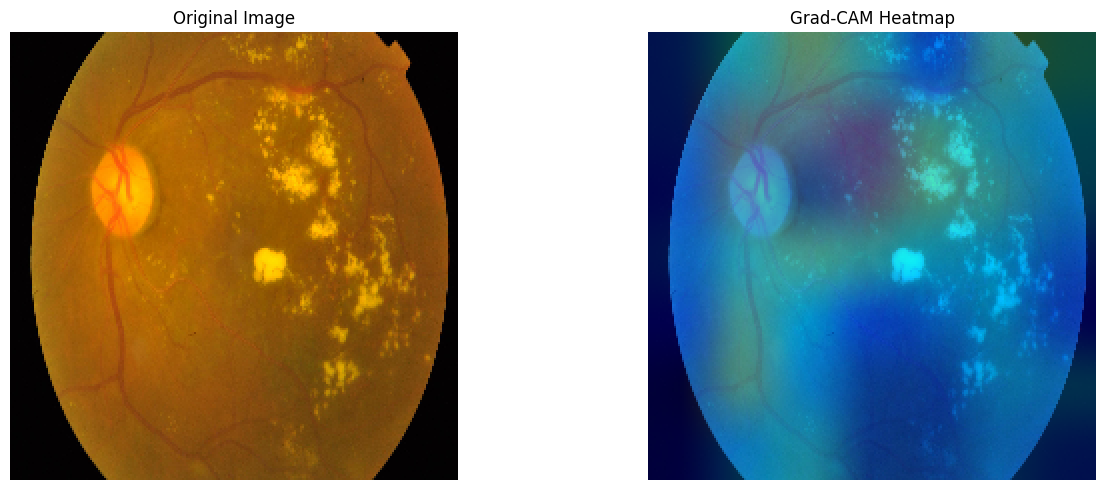

In [18]:
last_conv_layer_name = "conv5_block3_out"
# --- 8. Putting It All Together ---

image_path = (
    "./archive/colored_images/Severe/0104b032c141.png"  # Replace with your image path
)
preprocessed_image = preprocess_image_for_inference(image_path)
predictions = model.predict(preprocessed_image)
predicted_class = np.argmax(predictions[0])

print(f"Predicted class: {predicted_class}")
print(f"Probabilities: {predictions}")

heatmap = make_gradcam_heatmap(
    preprocessed_image, model, last_conv_layer_name, pred_index=predicted_class
)
display_gradcam(image_path, heatmap)

In [ ]:
# --- NLP Explanation Module ---


class DiabeticRetinopathyExplainer:
    def __init__(self, threshold=0.7):
        # 1. Predefined Explanations with Keywords:
        self.explanation_templates = {
            "microaneurysms": [
                "The model found evidence of microaneurysms, which are small, localized bulges in the blood vessels of the retina.",
                "The highlighted regions suggest the presence of microaneurysms, indicating early signs of diabetic retinopathy.",
            ],
            "exudates": [
                "The model detected exudates, which are yellow deposits of fats and proteins that leak from damaged blood vessels.",
                "The activation in these areas might be due to exudates, a common finding in diabetic retinopathy.",
            ],
            "hemorrhages": [
                "The model identified potential hemorrhages, which are areas of bleeding within the retina.",
                "The highlighted regions could indicate hemorrhages, suggesting a more advanced stage of diabetic retinopathy.",
            ],
            "neovascularization": [
                "The model found signs of neovascularization, which is the formation of new, abnormal blood vessels.",
                "The activation pattern suggests neovascularization, a serious complication of diabetic retinopathy that can lead to vision loss.",
            ],
            "normal": [
                "The model did not find strong evidence of diabetic retinopathy in the highlighted regions.",
                "The image appears relatively normal based on the model's analysis.",
            ],
        }

        # 2. Keyword Mapping to Regions (Simplified for this Example):
        self.keyword_regions = {
            "microaneurysms": [(0.2, 0.8), (0.2, 0.8)],  # Central region
            "exudates": [(0.1, 0.9), (0.1, 0.9)],  # Most of the image
            "hemorrhages": [(0.3, 0.7), (0.3, 0.7)],  # Central-ish region
            "neovascularization": [(0.0, 1.0), (0.0, 1.0)],  # Anywhere
        }

        self.threshold = threshold

    def analyze_heatmap_regions(self, heatmap):
        """
        Analyzes the heatmap to find the most activated regions.

        Args:
            heatmap: The Grad-CAM heatmap.

        Returns:
            A list of keywords corresponding to the activated regions.
        """
        activated_regions = []
        normalized_heatmap = heatmap / heatmap.max()

        for keyword, [(x_min, x_max), (y_min, y_max)] in self.keyword_regions.items():
            region_activation = normalized_heatmap[
                int(y_min * heatmap.shape[0]) : int(y_max * heatmap.shape[0]),
                int(x_min * heatmap.shape[1]) : int(x_max * heatmap.shape[1]),
            ]

            if region_activation.mean() > self.threshold:
                activated_regions.append(keyword)

        return activated_regions

    def generate_explanation(self, activated_regions):
        """
        Generates a text explanation based on activated regions.

        Args:
            activated_regions: A list of keywords corresponding to activated regions.

        Returns:
            A text explanation.
        """
        if not activated_regions:
            return self.explanation_templates["normal"][0]

        explanation = ""
        for region in activated_regions:
            if region in self.explanation_templates:
                explanation += (
                    np.random.choice(self.explanation_templates[region]) + " "
                )

        return explanation.strip()

In [21]:
explainer = DiabeticRetinopathyExplainer(threshold=0.7)  # Adjust threshold if needed
activated_regions = explainer.analyze_heatmap_regions(heatmap)
explanation = explainer.generate_explanation(activated_regions)

print(f"Explaination: {explanation}")

Explaination: The highlighted regions could indicate hemorrhages, suggesting a more advanced stage of diabetic retinopathy.
